---
### **Task 1.0 — Project Workspace Verification**

Confirm that the local CentOS workspace is ready and print its directory tree.

In [3]:
import os

# A small recursive printer that draws a tree of the project folder.
# We keep depth shallow because the workspace is shallow.
def show_tree(root, prefix="", max_depth=3, depth=0):
    if depth >= max_depth:
        return
    try:
        entries = sorted(os.listdir(root))
    except PermissionError:
        return
    for i, name in enumerate(entries):
        last = (i == len(entries) - 1)
        branch = "└── " if last else "├── "
        path   = os.path.join(root, name)
        print(prefix + branch + name)
        if os.path.isdir(path):
            new_prefix = prefix + ("    " if last else "│   ")
            show_tree(path, new_prefix, max_depth, depth + 1)


PROJECT_ROOT = os.path.expanduser("~/arabic_ai_detection")
print(f"Workspace: {PROJECT_ROOT}")
print("-" * 40)
show_tree(PROJECT_ROOT)
print("-" * 40)

Workspace: /home/student/arabic_ai_detection
----------------------------------------
├── data
│   ├── processed
│   │   └── abstracts_preprocessed.parquet
│   └── raw
│       └── abstracts_raw.parquet
├── models
│   ├── gbt_model
│   │   ├── data
│   │   ├── metadata
│   │   └── treesMetadata
│   ├── linear_svm
│   │   ├── data
│   │   └── metadata
│   ├── logistic_regression
│   │   ├── data
│   │   └── metadata
│   ├── random_forest
│   │   ├── data
│   │   ├── metadata
│   │   └── treesMetadata
│   └── tfidf_pipeline
│       ├── metadata
│       └── stages
├── reports
│   └── figures
│       ├── preprocessed_len_dist.png
│       ├── ttr_eda_distribution.png
│       └── wordcloud.png
├── streaming
│   ├── checkpoints
│   │   ├── .metadata.crc
│   │   ├── commits
│   │   ├── metadata
│   │   ├── offsets
│   │   └── sources
│   ├── inbox
│   │   ├── batch_000.json
│   │   ├── batch_001.json
│   │   ├── batch_002.json
│   │   ├── batch_003.json
│   │   └── batch_004.json
│   └── output

In [4]:

import seaborn  as sns
import pandas   as pd
import numpy    as np

In [29]:
%matplotlib inline
import matplotlib.pyplot as plt

---
## **Phase 1: Environment Setup & Data Acquisition**

> **Tasks:** 1.1 – 1.4


---
### Task 1.1 — Install Required Libraries

All Python packages needed by the pipeline. Safe to re-run — `pip install`
will skip packages that are already present.

In [6]:
import subprocess, sys

REQUIRED_PKGS = [
    "datasets",            # Hugging Face data loader
    "huggingface_hub",     # optional login
    "pyarabic",            # robust Arabic text helpers
    "regex",               # Unicode-aware regex
    "nltk",                # Arabic stop-words, ISRI stemmer
    "wordcloud",           # used in EDA
    "seaborn",             # statistical plots
    "pyarrow",             # Parquet backend
]

def install(pkg: str) -> None:
    """Install a single package quietly, trusting the standard PyPI hosts."""
    subprocess.check_call(
        [sys.executable, "-m", "pip", "install", "--quiet", pkg,
         "--trusted-host", "pypi.org",
         "--trusted-host", "files.pythonhosted.org"]
    )

for pkg in REQUIRED_PKGS:
    install(pkg)

print("All packages installed successfully.")

All packages installed successfully.


---
### **Task 1.2 — Initialize SparkSession (Local Mode)**

Create a local SparkSession tuned for a single CentOS VM.

In [7]:
import os
from pyspark        import SparkConf
from pyspark.sql    import SparkSession

# --- Directory layout ---
PROJECT_ROOT   = os.path.expanduser("~/arabic_ai_detection")
DATA_RAW       = os.path.join(PROJECT_ROOT, "data",    "raw")
DATA_PROCESSED = os.path.join(PROJECT_ROOT, "data",    "processed")
MODELS_DIR     = os.path.join(PROJECT_ROOT, "models")
REPORTS_DIR    = os.path.join(PROJECT_ROOT, "reports", "figures")

for d in (DATA_RAW, DATA_PROCESSED, MODELS_DIR, REPORTS_DIR):
    os.makedirs(d, exist_ok=True)

LOCAL_RAW_PATH = os.path.join(DATA_RAW, "abstracts_raw.parquet")

# --- Spark configuration ---
# local[*] => use all available CPU cores; Kryo => faster serialization.
spark_conf = (
    SparkConf()
        .setAppName("ArabicAITextDetection")
        .setMaster("local[*]")
        .set("spark.driver.memory",            "4g")
        .set("spark.executor.memory",          "4g")
        .set("spark.sql.shuffle.partitions",   "8")
        .set("spark.serializer",
             "org.apache.spark.serializer.KryoSerializer")
        .set("spark.driver.extraJavaOptions",  "-Dfile.encoding=UTF-8")
)

spark = SparkSession.builder.config(conf=spark_conf).getOrCreate()
sc    = spark.sparkContext
sc.setLogLevel("ERROR")     # less noise in Jupyter

print(f"Spark version       : {spark.version}")
print(f"Application name    : {sc.appName}")
print(f"Master URL          : {sc.master}")
print(f"Default parallelism : {sc.defaultParallelism}")
print(f"Project root        : {PROJECT_ROOT}")
print(f"Spark UI            : http://localhost:4040")

Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
26/05/18 22:47:25 WARN Utils: Your hostname, localhost.localdomain, resolves to a loopback address: 127.0.0.1; using 10.0.2.15 instead (on interface enp0s3)
26/05/18 22:47:25 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address
Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/05/18 22:47:27 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


Spark version       : 4.0.2
Application name    : ArabicAITextDetection
Master URL          : local[*]
Default parallelism : 1
Project root        : /home/student/arabic_ai_detection
Spark UI            : http://localhost:4040


---
### Task 1.3 — Download Dataset & Save to Local Parquet

Fetch the abstracts dataset from Hugging Face, flatten the wide
(`original` + 4 LLM columns) layout into long form, then persist it as a
single Parquet file under `data/raw/`.

In [8]:
from datasets import load_dataset

# Optional: authenticate if HF_TOKEN is exported in the environment
HF_TOKEN = os.environ.get("HF_TOKEN")
if HF_TOKEN:
    from huggingface_hub import login
    login(token=HF_TOKEN, add_to_git_credential=False)

dataset = load_dataset("KFUPM-JRCAI/arabic-generated-abstracts")

print("Dataset splits:", list(dataset.keys()))
for name, split in dataset.items():
    print(f"  {name}: {len(split):,} rows | columns: {split.column_names}")

Dataset splits: ['by_polishing', 'from_title', 'from_title_and_content']
  by_polishing: 2,851 rows | columns: ['original_abstract', 'allam_generated_abstract', 'jais_generated_abstract', 'llama_generated_abstract', 'openai_generated_abstract']
  from_title: 2,963 rows | columns: ['original_abstract', 'allam_generated_abstract', 'jais_generated_abstract', 'llama_generated_abstract', 'openai_generated_abstract']
  from_title_and_content: 2,574 rows | columns: ['original_abstract', 'allam_generated_abstract', 'jais_generated_abstract', 'llama_generated_abstract', 'openai_generated_abstract']


In [9]:
# --- Flatten the wide schema into one (text, label, source, generator) row per abstract ---

GENERATOR_MODELS = ("allam", "jais", "llama", "openai")
SPLIT_NAMES      = ("by_polishing", "from_title", "from_title_and_content")

def flatten_split(split_pdf: pd.DataFrame, split_name: str):
    """
    Yields dicts for one row of the wide table:
      - one row for the human (original) abstract
      - one row per LLM-generated abstract that is non-null
    Labels: 1 = human, 0 = AI.
    """
    for _, row in split_pdf.iterrows():
        # Human row
        yield {"abstract_text": row["original_abstract"],
               "source_split":  split_name,
               "generated_by":  "human",
               "label":         1}
        # AI rows
        for model in GENERATOR_MODELS:
            col = f"{model}_generated_abstract"
            if col in row and pd.notna(row[col]):
                yield {"abstract_text": row[col],
                       "source_split":  split_name,
                       "generated_by":  model,
                       "label":         0}

all_rows = []
for split_name in SPLIT_NAMES:
    split_pdf = dataset[split_name].to_pandas()
    all_rows.extend(flatten_split(split_pdf, split_name))

pdf = pd.DataFrame(all_rows)
print(f"Flattened DataFrame shape: {pdf.shape}")
print(pdf["label"].value_counts().rename({1: "Human (1)", 0: "AI (0)"}))

Flattened DataFrame shape: (41940, 4)
label
AI (0)       33552
Human (1)     8388
Name: count, dtype: int64


In [10]:
# Persist to Parquet — small, typed, columnar, Spark-friendly.
pdf.to_parquet(LOCAL_RAW_PATH, index=False, engine="pyarrow")

mb = os.path.getsize(LOCAL_RAW_PATH) / 1024 / 1024
print(f"Raw Parquet saved → {LOCAL_RAW_PATH}  ({mb:.2f} MB)")

Raw Parquet saved → /home/student/arabic_ai_detection/data/raw/abstracts_raw.parquet  (18.63 MB)


---
### Task 1.4 — Initial Data Exploration with Spark DataFrames

Load the Parquet back into Spark and run schema, class-balance, missing /
duplicate, length-statistics and a first stylometric feature (TTR).

In [11]:
from pyspark.sql       import functions as F
from pyspark.sql.types import StringType, IntegerType

# Always cache once after a heavy read — every subsequent action reuses it.
raw_df = spark.read.parquet(LOCAL_RAW_PATH).cache()

print("=== Dataset Schema ===")
raw_df.printSchema()

n_rows = raw_df.count()
print(f"\n=== Total Record Count ===\nTotal Rows: {n_rows:,}")

print("\n=== Sample Records ===")
raw_df.show(5, truncate=80)

=== Dataset Schema ===
root
 |-- abstract_text: string (nullable = true)
 |-- source_split: string (nullable = true)
 |-- generated_by: string (nullable = true)
 |-- label: long (nullable = true)




=== Total Record Count ===
Total Rows: 41,940

=== Sample Records ===
+--------------------------------------------------------------------------------+------------+------------+-----+
|                                                                   abstract_text|source_split|generated_by|label|
+--------------------------------------------------------------------------------+------------+------------+-----+
|كثيرا ما ارتبطت المصادر التاريخية في الأندلس خاصة منها كتب التراجم والفهرسات ...|by_polishing|       human|    1|
|يتناول هذا البحث موضوع التعليم بين النساء الأندلسيات من خلال دراسة المصادر ال...|by_polishing|       allam|    0|
|تدرس هذه الدراسة دور المرأة في التعليم في الأندلس من خلال مصادر تاريخية مثل ك...|by_polishing|        jais|    0|
|يُقدم هذا البحث دراسة شاملة حول حالة التعليم عند المرأة الأندلسية خلال العصور...|by_polishing|       llama|    0|
|صور نظام التعليم عند المرأة الأندلسية تستند إلى دراسة دقيقة للمصادر التاريخية...|by_polishing|      openai|    0|
+--------

In [12]:
# --- Class distribution (label × generator) ---
label_dist = (
    raw_df
        .groupBy("label", "generated_by")
        .count()
        .orderBy("label", "generated_by")
        .withColumn("percentage", F.round(F.col("count") / n_rows * 100, 2))
)

print("=== Class Distribution ===")
label_dist.show(truncate=False)

print("=== Source Split Distribution ===")
raw_df.groupBy("source_split").count().show()

=== Class Distribution ===
+-----+------------+-----+----------+
|label|generated_by|count|percentage|
+-----+------------+-----+----------+
|0    |allam       |8388 |20.0      |
|0    |jais        |8388 |20.0      |
|0    |llama       |8388 |20.0      |
|0    |openai      |8388 |20.0      |
|1    |human       |8388 |20.0      |
+-----+------------+-----+----------+

=== Source Split Distribution ===
+--------------------+-----+
|        source_split|count|
+--------------------+-----+
|        by_polishing|14255|
|from_title_and_co...|12870|
|          from_title|14815|
+--------------------+-----+



In [13]:
# --- Sanity checks: nulls & duplicates ---

print("=== Missing Values ===")
raw_df.select([
    F.sum(F.col(c).isNull().cast("int")).alias(c) for c in raw_df.columns
]).show()

unique_rows  = raw_df.dropDuplicates(["abstract_text"]).count()
duplicates   = n_rows - unique_rows
print(f"=== Duplicate Analysis ===\nDuplicate abstracts: {duplicates:,}")

=== Missing Values ===
+-------------+------------+------------+-----+
|abstract_text|source_split|generated_by|label|
+-------------+------------+------------+-----+
|            0|           0|           0|    0|
+-------------+------------+------------+-----+



[Stage 15:>                                                         (0 + 1) / 1]

=== Duplicate Analysis ===
Duplicate abstracts: 5,415


In [14]:
# --- Quick text-length stats by label ---

length_stats = (
    raw_df
        .withColumn("char_count", F.length("abstract_text"))
        .withColumn("word_count", F.size(F.split("abstract_text", r"\s+")))
        .groupBy("label")
        .agg(
            F.round(F.mean("char_count"),   2).alias("avg_chars"),
            F.round(F.stddev("char_count"), 2).alias("std_chars"),
            F.min("char_count").alias("min_chars"),
            F.max("char_count").alias("max_chars"),
            F.round(F.mean("word_count"),   2).alias("avg_words"),
        )
)

print("=== Length Stats per Label ===")
length_stats.show()

=== Length Stats per Label ===


[Stage 21:>                                                         (0 + 1) / 1]

+-----+---------+---------+---------+---------+---------+
|label|avg_chars|std_chars|min_chars|max_chars|avg_words|
+-----+---------+---------+---------+---------+---------+
|    1|   740.31|   226.59|      411|     1891|   119.16|
|    0|    654.6|   261.48|      170|    18459|   101.49|
+-----+---------+---------+---------+---------+---------+



#### Linguistic-diversity warm-up — Type-Token Ratio

A first taste of stylometry via the RDD API, before we settle on Spark
DataFrames + UDFs in Phase 3.

In [15]:
def _ttr_for_text(text: str) -> float:
    """Type-Token Ratio = unique words / total words."""
    if not text:
        return 0.0
    toks = text.split()
    return (len(set(toks)) / len(toks)) if toks else 0.0


ttr_rdd = (
    raw_df.select("abstract_text", "label").rdd
          .map(lambda r: (int(r["label"]), _ttr_for_text(r["abstract_text"])))
)

ttr_pdf = ttr_rdd.toDF(["label", "ttr"]).toPandas()
print(f"Collected {len(ttr_pdf):,} TTR values.")

Collected 41,940 TTR values.


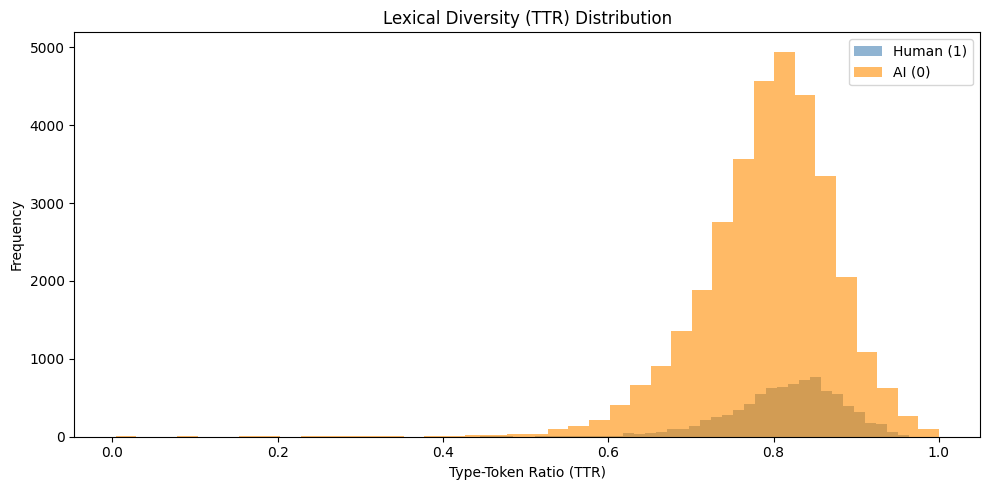

Plot saved → /home/student/arabic_ai_detection/reports/figures/ttr_eda_distribution.png
Average Human TTR: 0.8142  |  Average AI TTR: 0.7927


In [16]:
# Plot TTR distributions for Human vs AI side by side.

human_ttr = ttr_pdf.loc[ttr_pdf.label == 1, "ttr"]
ai_ttr    = ttr_pdf.loc[ttr_pdf.label == 0, "ttr"]

plt.figure(figsize=(10, 5))
plt.hist(human_ttr, bins=40, alpha=0.6, label="Human (1)", color="steelblue")
plt.hist(ai_ttr,    bins=40, alpha=0.6, label="AI (0)",    color="darkorange")
plt.xlabel("Type-Token Ratio (TTR)")
plt.ylabel("Frequency")
plt.title("Lexical Diversity (TTR) Distribution")
plt.legend()
plt.tight_layout()

ttr_plot_path = os.path.join(REPORTS_DIR, "ttr_eda_distribution.png")
plt.savefig(ttr_plot_path, dpi=150)
plt.show()

print(f"Plot saved → {ttr_plot_path}")
print(f"Average Human TTR: {human_ttr.mean():.4f}  |  Average AI TTR: {ai_ttr.mean():.4f}")

---
## **Phase 2: Distributed Data Preprocessing & Storage**

> **Tasks:** 2.1 – 2.3

In [17]:
import re
import nltk
from pyspark.sql.functions import udf
from pyspark.sql.types     import StringType

# NLTK Arabic stopwords are small — download once, cache on every worker.
nltk.download("stopwords", quiet=True)

# Pre-compile regexes once — much faster than re-compiling per row.
_DIACRITICS_RE = re.compile(r"[\u0617-\u061A\u064B-\u065F]")
_NON_ARABIC_RE = re.compile(r"[^\u0600-\u06FF\s]")
_MULTI_SPACE   = re.compile(r"\s+")


def strip_diacritics(text):
    """Remove Arabic tashkeel (short vowels + shadda)."""
    if not isinstance(text, str):
        return ""
    return _DIACRITICS_RE.sub("", text)


def normalise_letters(text):
    """Unify hamza/alef/yaa/taa-marbuta and keep only Arabic letters + space."""
    if not isinstance(text, str):
        return ""
    text = re.sub(r"[إأآا]", "ا", text)
    text = re.sub(r"ى",     "ي", text)
    text = re.sub(r"ة",     "ه", text)
    text = _NON_ARABIC_RE.sub(" ", text)
    return _MULTI_SPACE.sub(" ", text).strip()


def drop_stopwords(text):
    """Drop tokens that are in the Arabic stop-word list."""
    from nltk.corpus import stopwords
    if not isinstance(text, str):
        return ""
    stop_set = set(stopwords.words("arabic"))
    return " ".join(w for w in text.split() if w not in stop_set)


def stem_text(text):
    """ISRI light stem each token."""
    if not isinstance(text, str):
        return ""
    try:
        from nltk.stem.isri import ISRIStemmer
        stem = ISRIStemmer()
        return " ".join(stem.stem(w) for w in text.split())
    except Exception:
        # If NLTK data isn't fully downloaded, fall back to raw text.
        return text


def preprocess_arabic(text):
    """Full pipeline executed inside the UDF."""
    text = strip_diacritics(text)
    text = normalise_letters(text)
    text = drop_stopwords(text)
    text = stem_text(text)
    return text


# Register as a Spark UDF
preprocess_udf = udf(preprocess_arabic, StringType())

In [18]:
# --- Apply the UDF and clean obvious junk rows ---

preprocessed_df = (
    raw_df
        .filter(F.col("abstract_text").isNotNull()
                & (F.trim(F.col("abstract_text")) != ""))
        .dropDuplicates(["abstract_text"])
        .withColumn("abstract_text_clean", preprocess_udf(F.col("abstract_text")))
)

print(f"Preprocessed rows: {preprocessed_df.count():,}")
preprocessed_df.select("abstract_text", "abstract_text_clean").show(3, truncate=80)

Preprocessed rows: 36,525


[Stage 34:>                                                         (0 + 1) / 1]

+--------------------------------------------------------------------------------+--------------------------------------------------------------------------------+
|                                                                   abstract_text|                                                             abstract_text_clean|
+--------------------------------------------------------------------------------+--------------------------------------------------------------------------------+
|يُقدم هذا البحث دراسة شاملة حول حالة التعليم عند المرأة الأندلسية خلال العصور...|قدم بحث درس شمل حول حله علم راه دلس خلل عصر وسط كشف بحث خلل لسل ؤلف ارخ اندلس...|
|صور نظام التعليم عند المرأة الأندلسية تستند إلى دراسة دقيقة للمصادر التاريخية...|صور نظم علم راه دلس سند الي درس دقق صدر ارخ وثق حيه علماء ثقف دلس، سيم كتب رج...|
|انهيار دولة الموحدين يعود بشكل كبير للعوامل الثقافية، التي لا تقل أهمية عن ال...|هير دول وحد يعد شكل كبر عمل ثقافيه، تقل اهم عمل سيس عسكر بدئ فكر عقد ابن رت، ...|
+---------------

---
### Task 2.2 — Store Processed Data in Local Parquet

Partition by label so down-stream queries that filter on label only touch
their own files.

In [19]:
LOCAL_PROC_PATH = os.path.join(DATA_PROCESSED, "abstracts_preprocessed.parquet")

(
    preprocessed_df
        .repartition(8, "label")
        .write
        .mode("overwrite")
        .partitionBy("label")
        .parquet(LOCAL_PROC_PATH)
)

print(f"Processed data → {LOCAL_PROC_PATH}")
print("Disk partitions:", os.listdir(LOCAL_PROC_PATH))

[Stage 40:====================================>                     (5 + 1) / 8]

Processed data → /home/student/arabic_ai_detection/data/processed/abstracts_preprocessed.parquet
Disk partitions: ['label=0', 'label=1', '_SUCCESS', '._SUCCESS.crc']


In [20]:
# --- Read back and verify ---

verify_df = spark.read.parquet(LOCAL_PROC_PATH)
print(f"Row count from disk: {verify_df.count():,}")

# Walk the partition directory and sum file sizes.
total_bytes = sum(
    os.path.getsize(os.path.join(d, f))
    for d, _, files in os.walk(LOCAL_PROC_PATH)
    for f in files
)
print(f"Parquet size on disk: {total_bytes / 1024 / 1024:.2f} MB")

verify_df.select("label", "abstract_text_clean").show(3, truncate=80)

Row count from disk: 36,525
Parquet size on disk: 27.99 MB
+-----+--------------------------------------------------------------------------------+
|label|                                                             abstract_text_clean|
+-----+--------------------------------------------------------------------------------+
|    0|رجز بلد حضن عبر خطط ندر سلط ضوء علي قيم ربو اجتماعيه ثقف عرب سلم خلل فتر زمن ...|
|    0|مرس علم صنع علم عصر عولمه، راس مال مهيمن، حره شبه سؤل غيب درس ناخ علم سئد عصر...|
|    0|وزن يقع شكل صطلح شعر عرب هدف بحث الي درس حلل مفاهيم تعلق وزن يقع شعر عربي، تق...|
+-----+--------------------------------------------------------------------------------+
only showing top 3 rows


---
### Task 2.3 — EDA on Distributed Data + MapReduce Corpus Statistics

In [21]:
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt

# Cache the preprocessed table — we'll hit it many times in Phase 2/3.
proc_df = spark.read.parquet(LOCAL_PROC_PATH).cache()
print("Cleaned data cached for analysis.")

Cleaned data cached for analysis.


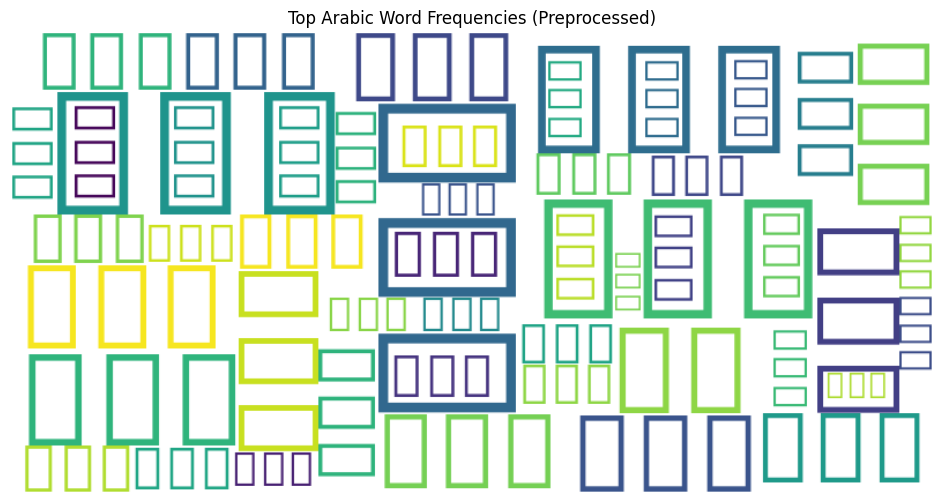

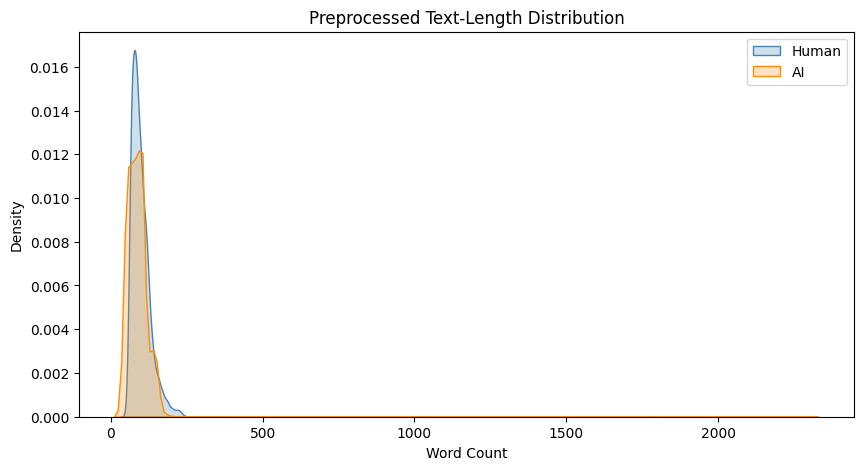

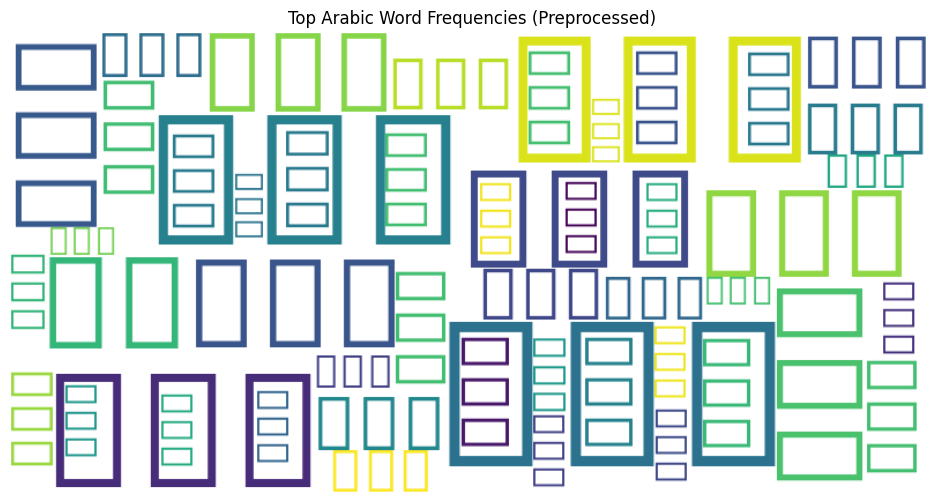

Word cloud → /home/student/arabic_ai_detection/reports/figures/wordcloud.png


In [30]:
# --- Word cloud of the 50 most frequent cleaned tokens ---

from wordcloud import WordCloud

top_words_pdf = (
    proc_df.select(F.explode(F.split("abstract_text_clean", r"\s+")).alias("word"))
           .groupBy("word").count()
           .orderBy(F.col("count").desc())
           .limit(50).toPandas()
)

try:
    wc = (WordCloud(width=800, height=400, background_color="white")
            .generate_from_frequencies(dict(zip(top_words_pdf["word"],
                                                top_words_pdf["count"]))))
    plt.figure(figsize=(12, 6))
    plt.imshow(wc, interpolation="bilinear")
    plt.axis("off")
    plt.title("Top Arabic Word Frequencies (Preprocessed)")

    wc_path = os.path.join(REPORTS_DIR, "wordcloud.png")
    plt.savefig(wc_path, dpi=150)
    plt.show()
    print(f"Word cloud → {wc_path}")
except Exception as e:
    print(f"Word cloud skipped: {e}")

In [23]:
# --- Top bigrams via Spark MLlib's NGram transformer ---

from pyspark.ml.feature import NGram

tokenized_df = proc_df.withColumn("tokens",
                                  F.split("abstract_text_clean", r"\s+"))
bigram_df    = NGram(n=2, inputCol="tokens", outputCol="bigrams") \
                    .transform(tokenized_df)

top_bigrams = (
    bigram_df.select(F.explode("bigrams").alias("bigram"))
             .groupBy("bigram").count()
             .orderBy(F.col("count").desc())
             .limit(20).toPandas()
)

print("=== Top 20 Bigrams ===")
print(top_bigrams.to_string(index=False))

[Stage 51:>                                                         (0 + 1) / 1]

=== Top 20 Bigrams ===
 bigram  count
درس الي  14458
بحث الي  11819
ركز علي  11781
هدف درس  10444
ضوء علي   9544
 الي ان   7724
هدف بحث   7214
اثر علي   6064
سلط ضوء   5447
الي كشف   5397
ضفه الي   4932
ورق بحث   4895
علي اهم   4724
نول بحث   4563
الي حلل   4405
بحث علي   3910
يمكن ان   3548
توقع ان   3415
الي درس   3394
ظهر نتج   3304


#### Manual MapReduce via RDDs

A textbook MapReduce: map each word → (word, 1), reduce by sum. This is
what Spark's groupBy().count() does under the hood — implementing it
explicitly to demonstrate understanding.

In [24]:
# --- Step 1: Build the (word, 1) → (word, total) pipeline ---

text_rdd = proc_df.select("abstract_text_clean").rdd.map(lambda r: r[0] or "")

word_counts_rdd = (
    text_rdd
        .flatMap(lambda t: t.split())             # MAP   : line → words
        .map(lambda w: (w, 1))                    # MAP   : word → (word, 1)
        .reduceByKey(lambda a, b: a + b)          # REDUCE: sum counts
        .sortBy(lambda kv: kv[1], ascending=False)
)

print("=== MapReduce — Top 20 Words ===")
for word, cnt in word_counts_rdd.take(20):
    print(f"  {word}: {cnt}")

=== MapReduce — Top 20 Words ===


[Stage 54:>                                                         (0 + 1) / 1]

  علي: 89367
  الي: 70929
  درس: 66307
  بحث: 53427
  علم: 37540
  ان: 32978
  حلل: 31232
  هدف: 30251
  جمع: 29295
  عمل: 26274
  خلل: 24473
  اثر: 23123
  خدم: 21862
  جزر: 20865
  فهم: 20757
  حقق: 20515
  عزز: 20009
  شكل: 19478
  نتج: 19365
  فعل: 18211


In [25]:
# --- Hapax legomena: words that appear exactly once in the whole corpus ---

hapax_count = word_counts_rdd.filter(lambda kv: kv[1] == 1).count()
vocab_size  = word_counts_rdd.count()

print(f"Total unique vocabulary : {vocab_size:,}")
print(f"Hapax legomena          : {hapax_count:,}  "
      f"({hapax_count / vocab_size * 100:.1f}% of vocab)")

Total unique vocabulary : 26,628
Hapax legomena          : 10,400  (39.1% of vocab)


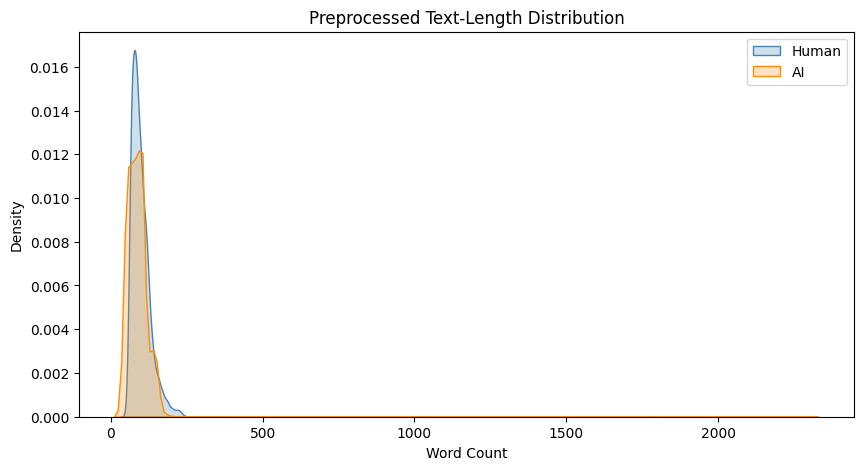

In [31]:
# --- KDE of preprocessed word counts, Human vs AI ---

import seaborn as sns

word_count_pdf = (
    proc_df
        .withColumn("word_count", F.size(F.split("abstract_text_clean", r"\s+")))
        .groupBy("label", "word_count").count()
        .toPandas()
)

def expand_counts(label_value):
    """Repeat each word_count value `count` times to feed a KDE."""
    sub = word_count_pdf[word_count_pdf.label == label_value]
    return sub.apply(lambda r: [r["word_count"]] * int(r["count"]),
                     axis=1).sum()

human_lengths = expand_counts(1)
ai_lengths    = expand_counts(0)

plt.figure(figsize=(10, 5))
sns.kdeplot(human_lengths, label="Human", fill=True, color="steelblue")
sns.kdeplot(ai_lengths,    label="AI",    fill=True, color="darkorange")
plt.title("Preprocessed Text-Length Distribution")
plt.xlabel("Word Count")
plt.legend()
plt.show()

In [27]:
# Save the figure created above
dist_path = os.path.join(REPORTS_DIR, "preprocessed_len_dist.png")
plt.savefig(dist_path)
print(f"Phase 2 analytics → {dist_path}")

Phase 2 analytics → /home/student/arabic_ai_detection/reports/figures/preprocessed_len_dist.png


In [32]:
# Free the cache before Phase 3 starts adding new columns.
proc_df.unpersist()
print("Memory cleared.")

Memory cleared.


---
## **Phase 3: Scalable Feature Engineering & Batch Modeling**

> **Tasks:** 3.1 – 3.5

In [33]:
import regex   # supports `\p{L}` for Unicode-letter matching
from pyspark.sql.functions import udf
from pyspark.sql.types     import DoubleType


# --- Tiny token helper used by features that need word counts ---

def arabic_tokens(text: str):
    """Pull out contiguous runs of Arabic characters as tokens."""
    if not isinstance(text, str) or not text.strip():
        return []
    return regex.findall(r"[\u0600-\u06FF]+", text)


# --- f002 — Letters Ratio -----------------------------------

@udf(DoubleType())
def f002_letters_ratio(text):
    """letters / total_characters. 0.0 for empty inputs."""
    if not isinstance(text, str) or len(text) == 0:
        return 0.0
    n_letters = len(regex.findall(r"\p{L}", text))
    return n_letters / len(text)


# --- f021 — Brunet's W --------------------------------------

@udf(DoubleType())
def f021_brunet_w(text):
    """
    Brunet's W = N ^ (V ^ -0.172).
    Falls back to 0.0 for very short texts (N < 2 or V < 2).
    """
    tokens = arabic_tokens(text)
    N = len(tokens)
    V = len(set(tokens))
    if N < 2 or V < 2:
        return 0.0
    return float(N ** (V ** -0.172))

print("Stylometric UDFs (f002, f021) registered.")

Stylometric UDFs (f002, f021) registered.


In [34]:
# --- Re-load the processed data and apply the UDFs ---

proc_df = spark.read.parquet(LOCAL_PROC_PATH)

feat_df = (
    proc_df
        .withColumn("f002_letters_ratio", f002_letters_ratio("abstract_text"))
        .withColumn("f021_brunet_w",      f021_brunet_w("abstract_text_clean"))
        .cache()
)

print(f"Feature engineering done. Rows: {feat_df.count():,}")
feat_df.select("label", "f002_letters_ratio", "f021_brunet_w").show(3)

[Stage 70:>                                                         (0 + 1) / 1]

Feature engineering done. Rows: 36,525
+-----+------------------+-----------------+
|label|f002_letters_ratio|    f021_brunet_w|
+-----+------------------+-----------------+
|    0|0.8267515923566879| 8.94371971796144|
|    0|0.8238993710691824|8.144263658515483|
|    0|       0.830078125|8.754466945062454|
+-----+------------------+-----------------+
only showing top 3 rows


---
### Task 3.2 — Advanced Features: TF-IDF Embedding (Spark MLlib)

The two stylometric scalars on their own are not enough — we combine them
with a 10 000-dim TF-IDF vector of the cleaned tokens.

In [35]:
from pyspark.ml         import Pipeline as MLPipeline
from pyspark.ml.feature import Tokenizer, HashingTF, IDF

tokenizer  = Tokenizer(inputCol="abstract_text_clean", outputCol="words_tokens")
hashing_tf = HashingTF(inputCol="words_tokens", outputCol="raw_tf",
                       numFeatures=10_000)
idf        = IDF(inputCol="raw_tf", outputCol="tfidf_features")

tfidf_pipeline = MLPipeline(stages=[tokenizer, hashing_tf, idf])
tfidf_model    = tfidf_pipeline.fit(feat_df)
tfidf_df       = tfidf_model.transform(feat_df)

print("TF-IDF pipeline fitted.")

[Stage 75:>                                                         (0 + 1) / 1]

TF-IDF pipeline fitted.


---
### Task 3.3 — Feature Assembly & Data Splitting

In [36]:
from pyspark.ml.feature import VectorAssembler

ACTIVE_STYLO_COLS = ["f002_letters_ratio", "f021_brunet_w"]

assembler = VectorAssembler(
    inputCols=ACTIVE_STYLO_COLS + ["tfidf_features"],
    outputCol="features",
    handleInvalid="skip",
)
assembled_df = assembler.transform(tfidf_df)

# 70 / 15 / 15 split
train_df, val_df, test_df = assembled_df.randomSplit([0.70, 0.15, 0.15], seed=42)

train_df.cache()
test_df.cache()

print(f"Train: {train_df.count():,} | Val: {val_df.count():,} | Test: {test_df.count():,}")

[Stage 83:>                                                         (0 + 1) / 1]

Train: 25,647 | Val: 5,402 | Test: 5,476


---
### Task 3.4 — Model Training & Evaluation

Four Spark MLlib classifiers benchmarked side by side:
`Logistic Regression` · `Random Forest` · `Linear SVM` · `Gradient-Boosted Trees`.

In [37]:
from pyspark.ml.classification import (LogisticRegression,
                                       RandomForestClassifier,
                                       LinearSVC,
                                       GBTClassifier)
from pyspark.ml.evaluation     import (BinaryClassificationEvaluator,
                                       MulticlassClassificationEvaluator)


def evaluate_model(model, data_df, name="Model"):
    """Compute AUC + Accuracy + F1 in one call."""
    preds = model.transform(data_df)

    bin_eval  = BinaryClassificationEvaluator(labelCol="label")
    multi_eval = MulticlassClassificationEvaluator(labelCol="label",
                                                   predictionCol="prediction")
    auc = bin_eval  .evaluate(preds, {bin_eval.metricName: "areaUnderROC"})
    acc = multi_eval.evaluate(preds, {multi_eval.metricName: "accuracy"})
    f1  = multi_eval.evaluate(preds, {multi_eval.metricName: "f1"})

    print(f"=== {name} ===")
    print(f"AUC: {auc:.4f} | Accuracy: {acc:.4f} | F1: {f1:.4f}\n")
    return {"AUC": auc, "Accuracy": acc, "F1": f1}


# 1. Logistic Regression (baseline)
lr_model  = LogisticRegression(featuresCol="features", labelCol="label",
                               maxIter=50, regParam=0.01).fit(train_df)
lr_res    = evaluate_model(lr_model, test_df, "Logistic Regression")

# 2. Random Forest
rf_model  = RandomForestClassifier(featuresCol="features", labelCol="label",
                                   numTrees=100, maxDepth=10,
                                   seed=42).fit(train_df)
rf_res    = evaluate_model(rf_model, test_df, "Random Forest")

# 3. Linear SVM
svm_model = LinearSVC(featuresCol="features", labelCol="label",
                      maxIter=50).fit(train_df)
svm_res   = evaluate_model(svm_model, test_df, "Linear SVM")

# 4. GBT
gbt_model = GBTClassifier(featuresCol="features", labelCol="label",
                          maxIter=50, maxDepth=8,
                          seed=42).fit(train_df)
gbt_res   = evaluate_model(gbt_model, test_df, "Gradient Boosted Trees")

=== Logistic Regression ===
AUC: 0.9660 | Accuracy: 0.9538 | F1: 0.9500



=== Random Forest ===
AUC: 0.9682 | Accuracy: 0.9207 | F1: 0.8828



=== Linear SVM ===
AUC: 0.9486 | Accuracy: 0.9410 | F1: 0.9428



=== Gradient Boosted Trees ===
AUC: 0.9585 | Accuracy: 0.9491 | F1: 0.9431



---
### Task 3.5 — Model Persistence

Serialize every trained model + the TF-IDF pipeline to disk so that
streaming inference can load them without re-training.

In [40]:
os.makedirs(MODELS_DIR, exist_ok=True)

# Classifiers
lr_model.write().overwrite().save(os.path.join(MODELS_DIR, "logistic_regression"))
rf_model.write().overwrite().save(os.path.join(MODELS_DIR, "random_forest"))
svm_model.write().overwrite().save(os.path.join(MODELS_DIR, "linear_svm"))
gbt_model.write().overwrite().save(os.path.join(MODELS_DIR, "gbt_model"))

# Feature pipeline
tfidf_model.write().overwrite().save(os.path.join(MODELS_DIR, "tfidf_pipeline"))

print(f"Saved 4 models + TF-IDF pipeline → {MODELS_DIR}")
print("Files on disk:", os.listdir(MODELS_DIR))

Saved 4 models + TF-IDF pipeline → /home/student/arabic_ai_detection/models
Files on disk: ['logistic_regression', 'random_forest', 'linear_svm', 'gbt_model', 'tfidf_pipeline']


---
## **Phase 4: Stream Processing & Comprehensive Evaluation**

> **Tasks:** 4.1 – 4.4

---
### Task 4.1 — Stream Simulation via Local File Source

Spark Structured Streaming can monitor a local directory. We write a few
JSON files to it as if they came from Kafka or another producer.

In [41]:
import json, time

STREAM_IN   = os.path.join(PROJECT_ROOT, "streaming", "inbox")
STREAM_OUT  = os.path.join(PROJECT_ROOT, "streaming", "output")
STREAM_CKPT = os.path.join(PROJECT_ROOT, "streaming", "checkpoints")

for p in (STREAM_IN, STREAM_OUT, STREAM_CKPT):
    os.makedirs(p, exist_ok=True)

# 50 samples taken from the held-out test set
sample_rows = (
    test_df.select("label", "abstract_text", "abstract_text_clean")
           .limit(50).collect()
)

# 5 batches × 10 records = 50 total, written one file per batch
for batch_id in range(5):
    batch = sample_rows[batch_id * 10 : (batch_id + 1) * 10]
    out_file = os.path.join(STREAM_IN, f"batch_{batch_id:03d}.json")

    with open(out_file, "w", encoding="utf-8") as fh:
        for row in batch:
            payload = {
                "abstract_text":       row["abstract_text"],
                "abstract_text_clean": row["abstract_text_clean"],
                "label":               int(row["label"]),
            }
            fh.write(json.dumps(payload, ensure_ascii=False) + "\n")

    print(f"Batch {batch_id} written → {out_file}")
    time.sleep(0.5)

print("\nStreaming workspace ready.")

Batch 0 written → /home/student/arabic_ai_detection/streaming/inbox/batch_000.json
Batch 1 written → /home/student/arabic_ai_detection/streaming/inbox/batch_001.json
Batch 2 written → /home/student/arabic_ai_detection/streaming/inbox/batch_002.json
Batch 3 written → /home/student/arabic_ai_detection/streaming/inbox/batch_003.json
Batch 4 written → /home/student/arabic_ai_detection/streaming/inbox/batch_004.json

Streaming workspace ready.


---
### Task 4.2 — Real-Time Deployment with Spark Structured Streaming

In [42]:
from pyspark.sql.types import StructType, StructField, StringType, IntegerType

# JSON schema — must match what Task 4.1 wrote.
stream_schema = StructType([
    StructField("abstract_text",       StringType(),  True),
    StructField("abstract_text_clean", StringType(),  True),
    StructField("label",               IntegerType(), True),
])

# 1. Source — monitor the inbox folder
raw_stream_df = (
    spark.readStream
         .schema(stream_schema)
         .option("maxFilesPerTrigger", 1)   # one JSON per trigger
         .json(STREAM_IN)
)

# 2. Same feature extractors as the batch pipeline
stream_feat = (
    raw_stream_df
        .withColumn("f002_letters_ratio", f002_letters_ratio("abstract_text"))
        .withColumn("f021_brunet_w",      f021_brunet_w("abstract_text_clean"))
)

# 3. Same TF-IDF + assembler + model
stream_tfidf       = tfidf_model.transform(stream_feat)
stream_assembled   = assembler.transform(stream_tfidf)
stream_predictions = rf_model.transform(stream_assembled)   # use the RF model

# 4. Sink — write each prediction batch to Parquet
stream_query = (
    stream_predictions
        .select("abstract_text", "label", "prediction", "probability")
        .writeStream
        .outputMode("append")
        .format("parquet")
        .option("checkpointLocation", STREAM_CKPT)
        .option("path",               STREAM_OUT)
        .trigger(processingTime="5 seconds")
        .start()
)

print(f"Streaming query active: {stream_query.isActive}")
time.sleep(30)
stream_query.stop()
print("Streaming query stopped.")

Streaming query active: True
Streaming query stopped.


In [43]:
# --- Read back what the stream produced ---

import glob

result_files = glob.glob(os.path.join(STREAM_OUT, "**", "*.parquet"),
                         recursive=True)

if result_files:
    stream_results_df = spark.read.parquet(STREAM_OUT)
    n_preds = stream_results_df.count()
    print(f"Streamed predictions: {n_preds}")
    stream_results_df.select("label", "prediction").show(5)

    correct = stream_results_df.filter(
        F.col("label") == F.col("prediction").cast("int")
    ).count()
    print(f"Live accuracy: {correct / n_preds * 100:.2f}%")
else:
    print("No streaming output files found yet.")

Streamed predictions: 50
+-----+----------+
|label|prediction|
+-----+----------+
|    1|       0.0|
|    0|       0.0|
|    0|       0.0|
|    1|       0.0|
|    1|       0.0|
+-----+----------+
only showing top 5 rows
Live accuracy: 74.00%


---
### Task 4.3 — Comprehensive Evaluation: Metrics, ROC, Confusion Matrices

In [44]:
models_to_eval = {
    "Logistic Regression":   lr_model,
    "Random Forest":         rf_model,
    "Linear SVM":            svm_model,
    "Gradient Boosted Trees": gbt_model,
}

results = {name: evaluate_model(m, test_df, name) for name, m in models_to_eval.items()}

=== Logistic Regression ===
AUC: 0.9660 | Accuracy: 0.9538 | F1: 0.9500



=== Random Forest ===
AUC: 0.9682 | Accuracy: 0.9207 | F1: 0.8828

=== Linear SVM ===
AUC: 0.9486 | Accuracy: 0.9410 | F1: 0.9428



=== Gradient Boosted Trees ===
AUC: 0.9585 | Accuracy: 0.9491 | F1: 0.9431



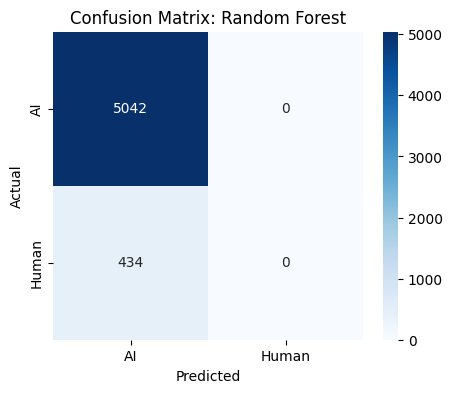

In [45]:
# --- Confusion matrix for the best performer ---

import seaborn as sns
import numpy   as np

def plot_confusion(model, data_df, name):
    preds = model.transform(data_df)
    rows  = preds.groupBy("label", "prediction").count().collect()

    cm = np.zeros((2, 2), dtype=int)
    for r in rows:
        i, j = int(r["label"]), int(r["prediction"])
        if 0 <= i < 2 and 0 <= j < 2:
            cm[i, j] = int(r["count"])

    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=["AI", "Human"], yticklabels=["AI", "Human"])
    plt.title(f"Confusion Matrix: {name}")
    plt.xlabel("Predicted"); plt.ylabel("Actual")
    plt.show()

plot_confusion(rf_model, test_df, "Random Forest")

---
### Task 4.4 — Scalability Benchmark: Throughput Analysis

Partitions:  4 | Time: 3.66s


Partitions:  8 | Time: 2.79s


Partitions: 16 | Time: 2.65s


[Stage 1256:>                                                       (0 + 1) / 1]

Partitions: 32 | Time: 2.88s


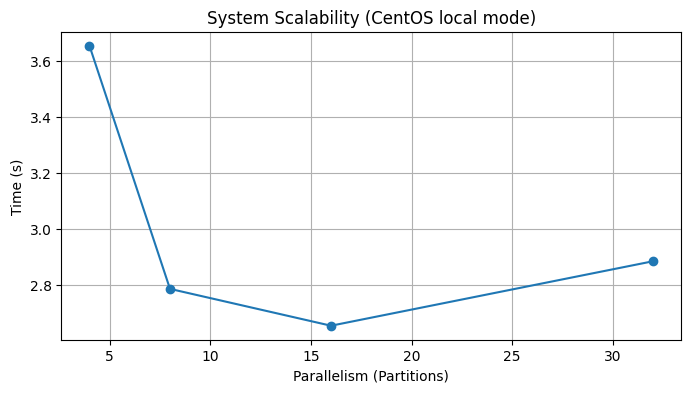

In [46]:
# Vary the number of shuffle partitions and time a heavy aggregation.

partition_configs = [4, 8, 16, 32]
batch_times       = []

for p in partition_configs:
    spark.conf.set("spark.sql.shuffle.partitions", str(p))
    t0 = time.time()
    _  = assembled_df.repartition(p).count()
    dt = time.time() - t0
    batch_times.append(dt)
    print(f"Partitions: {p:2d} | Time: {dt:.2f}s")

plt.figure(figsize=(8, 4))
plt.plot(partition_configs, batch_times, marker="o")
plt.title("System Scalability (CentOS local mode)")
plt.xlabel("Parallelism (Partitions)"); plt.ylabel("Time (s)")
plt.grid(True)
plt.show()

---
## **Phase 5: Analysis, Interpretation & Final Reporting**

> **Tasks:** 5.1 – 5.3

---
### Task 5.1 — Model Comparison Summary

In [47]:
summary_rows = []
all_results  = {
    "Logistic Regression":   lr_res,
    "Random Forest":         rf_res,
    "Linear SVM":            svm_res,
    "Gradient Boosted Trees": gbt_res,
}

for name, metrics in all_results.items():
    summary_rows.append({
        "Model":     name,
        "Accuracy":  round(metrics["Accuracy"], 4),
        "F1-Score":  round(metrics["F1"],       4),
        "AUC-ROC":   round(metrics["AUC"],      4) if metrics["AUC"] else "N/A",
        "Framework": "Spark MLlib (CentOS Local)",
    })

summary_df = (
    pd.DataFrame(summary_rows)
      .sort_values("F1-Score", ascending=False)
)

print("=== Final Model Performance Comparison ===")
print(summary_df.to_string(index=False))

=== Final Model Performance Comparison ===
                 Model  Accuracy  F1-Score  AUC-ROC                  Framework
   Logistic Regression    0.9538    0.9500   0.9660 Spark MLlib (CentOS Local)
Gradient Boosted Trees    0.9491    0.9431   0.9585 Spark MLlib (CentOS Local)
            Linear SVM    0.9410    0.9428   0.9486 Spark MLlib (CentOS Local)
         Random Forest    0.9207    0.8828   0.9682 Spark MLlib (CentOS Local)


---
### Task 5.2 — Feature Importance Analysis

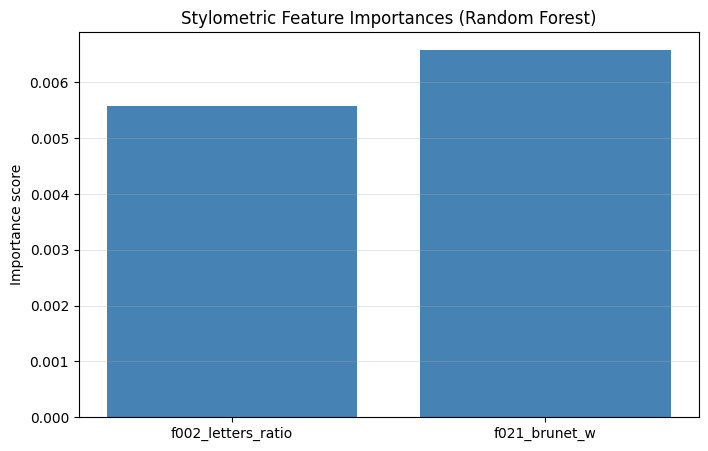

Feature-importance plot → /home/student/arabic_ai_detection/reports/figures/feature_importances.png


In [48]:
# Pull stylometric weights out of the Random Forest model.

importances = rf_model.featureImportances.toArray()

# The first ACTIVE_STYLO_COLS entries are the stylometric features;
# the rest are TF-IDF dimensions.
n_stylo   = len(ACTIVE_STYLO_COLS)
stylo_imp = importances[:n_stylo]

plt.figure(figsize=(8, 5))
plt.bar(ACTIVE_STYLO_COLS, stylo_imp, color="steelblue")
plt.ylabel("Importance score")
plt.title("Stylometric Feature Importances (Random Forest)")
plt.grid(axis="y", alpha=0.3)

fi_path = os.path.join(REPORTS_DIR, "feature_importances.png")
plt.savefig(fi_path, dpi=150)
plt.show()
print(f"Feature-importance plot → {fi_path}")

---
### Task 5.3 — Reproducibility Artefact

In [49]:
req_path = os.path.join(PROJECT_ROOT, "requirements.txt")
pkg_list = subprocess.run(
    [sys.executable, "-m", "pip", "freeze"],
    capture_output=True, text=True,
).stdout

with open(req_path, "w") as fh:
    fh.write(pkg_list)

print(f"requirements.txt → {req_path}")

requirements.txt → /home/student/arabic_ai_detection/requirements.txt


In [50]:
# Free the cluster resources at the end of the run.
spark.stop()
print("SparkSession terminated.")
print(f"Final figures available in: {REPORTS_DIR}")

SparkSession terminated.
Final figures available in: /home/student/arabic_ai_detection/reports/figures
